# ***Code-Agent***

## ***LLM Setup***

In [30]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model = "llama3:latest"
)
#llm.invoke("What is machine learning").content

## **Define State**

In [31]:
from typing import TypedDict,Optional

class AgentState(TypedDict):
    user_input : str
    input_type: Optional[str]
    explanation : Optional[str]
    solution : Optional[str]
    review : Optional[str]

    next_step : Optional[str]
    final_output : Optional[str]

## **Router Agent**

In [32]:
def router_agent(state):
    prompt = f"""
    Classify the input into one word:
    explain OR solve OR review

    Input:
    {state['user_input']}
    """

    raw = llm.invoke(prompt).content.strip().lower()

    # normalize output (CRITICAL)
    if "review" in raw:
        step = "review"
    elif "solve" in raw:
        step = "solve"
    elif "explain" in raw:
        step = "explain"
    else:
        step = "explain"  # safe fallback

    print("Router raw output:", raw)  # debug

    return {
        "input_type": step,
        "next_step": step   # MUST exist
    }

## **Explain Agent**

In [33]:
def explain_agent(state):
    prompt = f"""
Explain this programming concept simply:
{state['user_input']}
    """
    response = llm.invoke(prompt).content.strip()
    return {'explanation': response,'next_step':'final'}

## **Solve Agent**

In [34]:
def solve_agent(state):
    prompt = f"""
    Solve this coding problem with explaination:
    {state['user_input']}
    """ 
    solution = llm.invoke(prompt).content

    return{
        "solution": solution,
        "next_step": "final"
    }


## **Review Agent**

In [35]:
def review_agent(state):
    prompt = f"""
    Review this code .Find issues and suggest fixes:
    {state['user_input']}
    """
    review = llm.invoke(prompt).content 
    return {
        'review': review,
        'next_step':'solve'
    }

## **Final Combiner**

In [36]:
def final_agent(state):
    output = ""
    if state.get("review"):
        output += f"Review:\n{state['review']}\n\n"
    if state.get("explanation"):
        output += f"Explanation:\n{state['explanation']}\n\n"
    if state.get("solution"):
        output += f"Solution:\n{state['solution']}\n\n"
    return {'final_output': output}

## **Build LangGraph**

In [37]:
from langgraph.graph import StateGraph,START,END

graph = StateGraph(AgentState)


# Nodes

graph.add_node("router",router_agent)
graph.add_node("explain",explain_agent)
graph.add_node("solve",solve_agent)
graph.add_node("review",review_agent)
graph.add_node("final",final_agent)


## **Routing Logic**

In [38]:
def route_from_router(state):
    return state.get("next_step", "explain")  # fallback

In [39]:
graph.add_conditional_edges(
    "router",
    route_from_router,
    {
        "explain": "explain",
        "solve": "solve",
        "review": "review"
    }
)

## **Agent Chaining**

In [40]:
graph.add_edge(START, "router")

# review -> solve(fix code)
graph.add_edge("review","solve")
#solve -> final
graph.add_edge("solve","final")
#explain -> final
graph.add_edge("explain","final")
#final-> end 
graph.add_edge("final",END)

## **Entry Point**

In [41]:
graph.set_entry_point("router")
app = graph.compile()

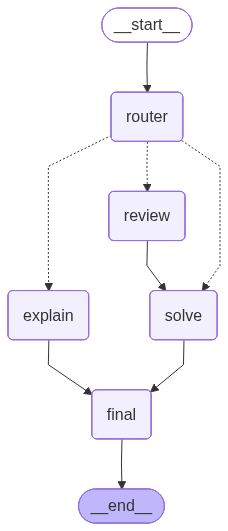

In [42]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

## **Run Example**

In [43]:
input_data = {
    "user_input": "Check this python code for errors : def add(a,b)  return a - b"
}
result = app.invoke(input_data)
print(result['final_output'])

Router raw output: **review**

the input is asking you to check and evaluate the python code, which means reviewing it for any potential issues or errors.
Review:
The given Python code has two main issues:

1. The function definition is missing parentheses: In Python, when defining a function, you need to use parentheses `()` after the function name and parameters. So, it should be `def add(a, b):`

2. The return statement is not indented correctly: The `return` statement should be aligned with the code inside the function.

Here's the corrected code:

```Python
def add(a, b):
    return a - b
```

However, if we were to interpret this code as an arithmetic operation (i.e., subtraction instead of addition), it would work correctly.

Solution:
A nice simple one!

The error in the code is that the `return` statement is not indented correctly. In Python, indentation (spaces or tabs) is used to denote block-level structure, such as function bodies.

Here's the corrected code:
```python
def